In [1]:
!pip install pandas

In [2]:
import pandas as pd
import sqlite3
from sqlite3 import Error

In [3]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [4]:
checker = pd.read_sql("SELECT * FROM checker WHERE uid LIKE 'user_%'", connection)
pageviews = pd.read_sql("SELECT * FROM pageviews WHERE uid LIKE 'user_%'", connection)

checker["date"] = pd.to_datetime(checker["timestamp"]).dt.date 
pageviews["date"] = pd.to_datetime(pageviews["datetime"]).dt.date

In [5]:
agg_pageviews = pageviews.groupby("date").agg(**{"views": ("date", "count")})
agg_checker = checker.groupby("date").agg(**{"commits": ("date", "count")})

agg_pageviews = agg_pageviews.reset_index()
agg_checker = agg_checker.reset_index()

final_df = pd.merge(agg_pageviews, agg_checker, on="date")

final_df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


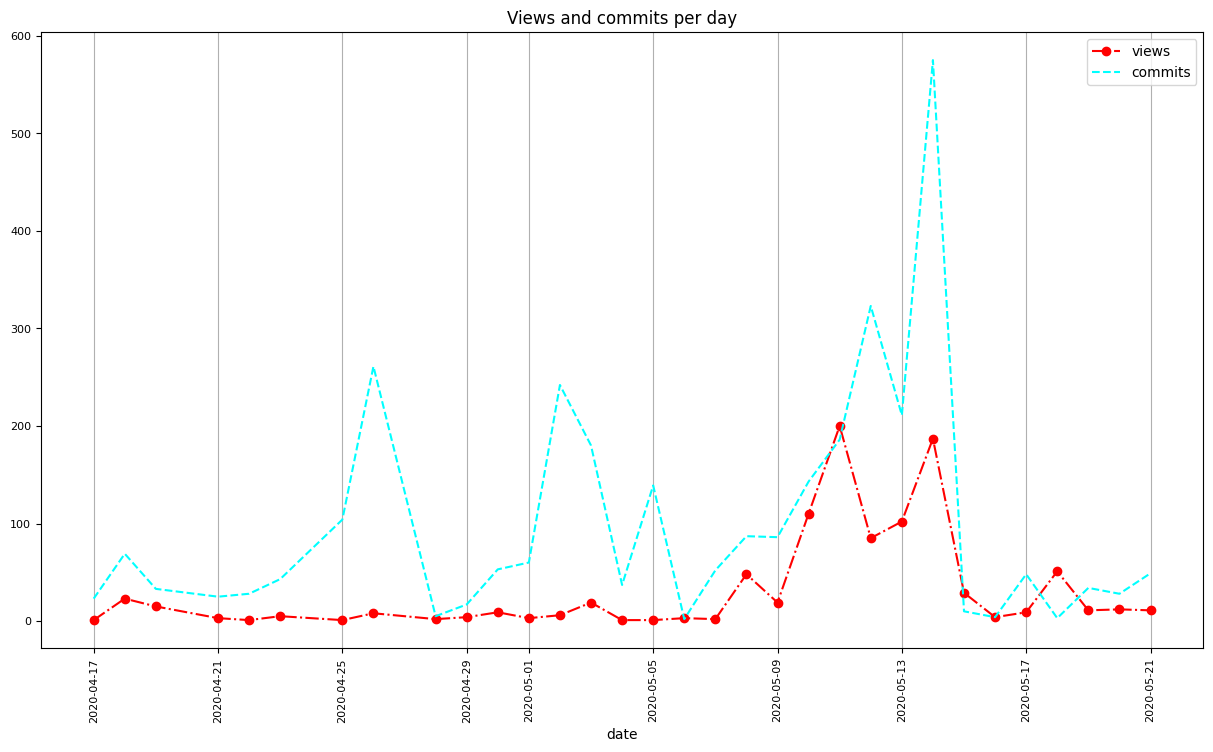

In [6]:
graf= final_df.plot(x = "date", fontsize=8, figsize=(15, 8), title="Views and commits per day", rot=90, color=["red", "cyan"])

graf.lines[0].set_linestyle("-.")
graf.lines[1].set_linestyle("--")

graf.lines[0].set_marker("o")
graf.grid(axis="x")

graf.legend()

#### Сколько раз количество просмотров было больше 150?
#### Ответ: 2

In [7]:
connection.close()